In [9]:
import pandas as pd
import numpy as np
from numpy.linalg import matrix_rank

df = pd.read_excel(r"C:\Users\ivysa\Downloads\Lab Session Data.xlsx", sheet_name="Purchase data")
X = df[["Candies (#)", "Mangoes (Kg)", "Milk Packets (#)"]].values      # dataframe indexing 
y = df["Payment (Rs)"].values

print("X =")
print(X)

print("\ny =")
print(y)

print("\nRank of feature matrix X:")
print(matrix_rank(X))

X_pinv = np.linalg.pinv(X)
c = np.dot(X_pinv, y)
print("\nCost of each product:")
print(c)
print("Candy: ", c[0])
print("Mango: ", c[1])
print("Milk Packet: ", c[2])

X =
[[20  6  2]
 [16  3  6]
 [27  6  2]
 [19  1  2]
 [24  4  2]
 [22  1  5]
 [15  4  2]
 [18  4  2]
 [21  1  4]
 [16  2  4]]

y =
[386 289 393 110 280 167 271 274 148 198]

Rank of feature matrix X:
3

Cost of each product:
[ 1. 55. 18.]
Candy:  0.9999999999999967
Mango:  55.00000000000003
Milk Packet:  18.000000000000007


Manual Mean : 1560.6634538152598
Built-in Mean: 1560.6634538152612
Manual Time for Mean: 8.371999865630642e-05
Built-in Time for Mean: 3.3639997127465904e-05

Manual Variance : 1.0
Built-in Variance: 58496.49239931613
Manual Time for Variance: 0.00031741000129841267
Built-in Time for Variance: 0.0001898300019092858

Sample Mean of Wednesday: 1550.7060000000001
Population mean: 1560.6634538152598

Sample Mean of April: 1698.9526315789474
Population mean: 1560.6634538152598

Probability of making loss: 0.4979919678714859
Probability of making profit on Wendesday: 0.42
Conditional probability of making a profit, given that today is Wednesday: 0.42


<function matplotlib.pyplot.show(close=None, block=None)>

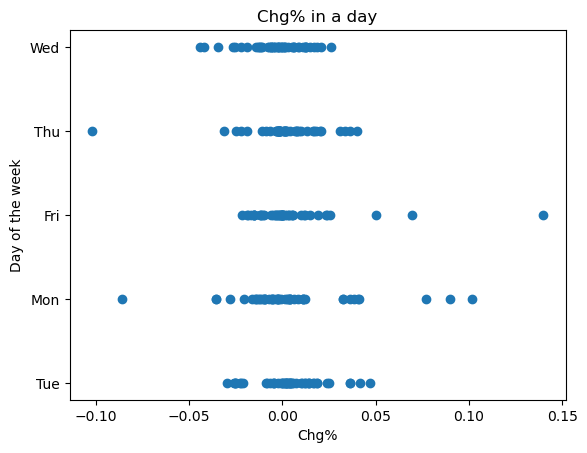

In [43]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

sp = (pd.read_excel(r"C:\Users\ivysa\Downloads\Lab Session Data.xlsx", sheet_name="IRCTC Stock Price"))

def stockPriceMean(column):
    sum = 0
    for price in column:
        sum += price
    avg = sum / len(column)
    return avg

def stockPriceVariance(column):
    mean = stockPriceMean(column)
    varSum = 0
    for price in column:
        varSum += (price - mean)**2
    variance = varSum / varSum
    return variance

def builtinMean(column):
    return np.mean(column)

def builtinVariance(data):
    return np.var(data)

def executionTime(function, column, runs = 10):
    total_time = 0
    for _ in range(runs):
        start = time.perf_counter()
        result = function(column)
        end = time.perf_counter()
        total_time += (end - start)
    avg_time = total_time /runs
    return result, avg_time

manual_result_mean, manual_time_mean = executionTime(stockPriceMean, sp["Price"].values)
builtin_result_mean, builtin_time_mean = executionTime(builtinMean, sp["Price"].values)

print("Manual Mean :", manual_result_mean)
print("Built-in Mean:", builtin_result_mean)

print("Manual Time for Mean:", manual_time_mean)
print("Built-in Time for Mean:", builtin_time_mean)
    
manual_result_variance, manual_time_variance = executionTime(stockPriceVariance, sp["Price"].values)
builtin_result_variance, builtin_time_variance = executionTime(builtinVariance, sp["Price"].values)

print("\nManual Variance :", manual_result_variance)
print("Built-in Variance:", builtin_result_variance)

print("Manual Time for Variance:", manual_time_variance)
print("Built-in Time for Variance:", builtin_time_variance)    

wednesdayPrice = sp[sp["Day"] == "Wed"]["Price"]
print("\nSample Mean of Wednesday:", wednesdayPrice.mean())
print("Population mean:", stockPriceMean(sp["Price"].values))

sp["Date"] = pd.to_datetime(sp["Date"])
AprPrices = sp[sp["Date"].dt.month == 4]["Price"]
print("\nSample Mean of April:", AprPrices.mean())
print("Population mean:", stockPriceMean(sp["Price"].values))

lossProb = (sp["Chg%"].apply(lambda x: x < 0).sum() / len(sp))
print("\nProbability of making loss:", lossProb)

profitProb_Wed = sp[sp["Day"] == "Wed"]["Chg%"]
profitProb = (profitProb_Wed.apply(lambda x: x > 0).sum() / len(profitProb_Wed))
print("Probability of making profit on Wendesday:", profitProb)

wednesday = sp[sp["Day"] == "Wed"]
profitWed = len(wednesday[wednesday["Chg%"] > 0])
totalWed = len(wednesday)
probability = profitWed / totalWed    #conditional probability   
print("Conditional probability of making a profit, given that today is Wednesday:", probability)

plt.scatter(sp["Chg%"].values, sp["Day"].values)
plt.title("Chg% in a day")
plt.xlabel("Chg%")
plt.ylabel("Day of the week")
plt.show